In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('iperf_timeseries.csv')

# Calculate the ratio mbps_achieved / target_bw_mbps
df['achieved_target_ratio'] = df['mbps_achieved'] / df['target_bw_mbps']

# Display the first few rows of the DataFrame with the new column
display(df.head())

,flow_id,target_bw_mbps,scheduled_flow_start_s,interval_index,absolute_time_s,interval_start_s,interval_end_s,bytes_transferred,bits_per_second,mbps_achieved,...,snd_cwnd_bytes,pmtu,rtt_us,rttvar_us,omitted,cpu_utilization_local_pct,cpu_utilization_remote_pct,congestion_algorithm,max_snd_cwnd_bytes,achieved_target_ratio
0,0,6.56,11.26,0,11.76,0.0,1.0,668336,5345469,5.3455,...,66608,1500,121064,405,False,3.169414,0.232682,cubic,92672,0.814863
1,0,6.56,11.26,1,12.76,1.0,2.0,655360,5243048,5.2430,...,82536,1500,122271,2386,False,3.169414,0.232682,cubic,92672,0.799238
2,0,6.56,11.26,2,13.76,2.0,3.0,655360,5243205,5.2432,...,91224,1500,121136,458,False,3.169414,0.232682,cubic,92672,0.799268
3,0,6.56,11.26,3,14.76,3.0,4.0,786432,6291972,6.2920,...,92672,1500,120997,599,False,3.169414,0.232682,cubic,92672,0.959146
4,0,6.56,11.26,4,15.76,4.0,5.0,655360,5242345,5.2423,...,92672,1500,120988,685,False,3.169414,0.232682,cubic,92672,0.799131


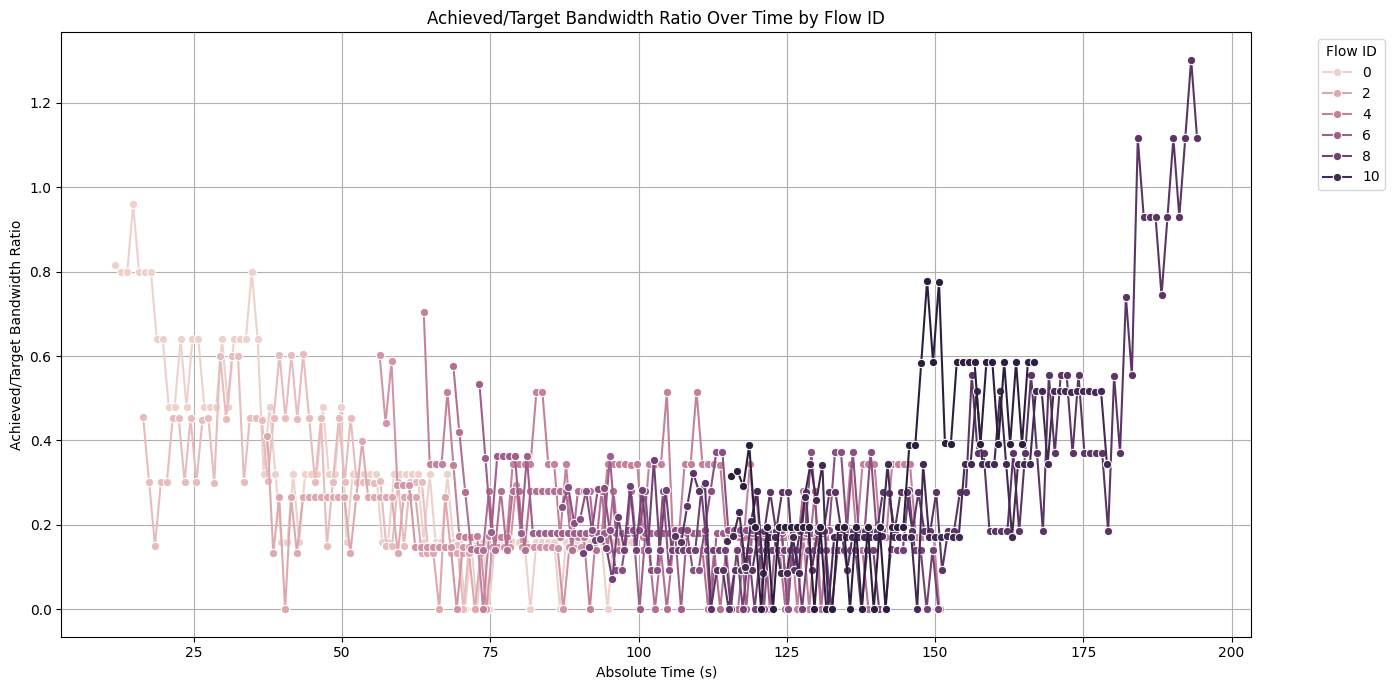

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df,
    x='absolute_time_s',
    y='achieved_target_ratio',
    hue='flow_id',
    marker='o', # Add markers to show individual data points
    dashes=False # Ensure distinct lines if there are many flow_ids
)

plt.title('Achieved/Target Bandwidth Ratio Over Time by Flow ID')
plt.xlabel('Absolute Time (s)')
plt.ylabel('Achieved/Target Bandwidth Ratio')
plt.grid(True)
plt.legend(title='Flow ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

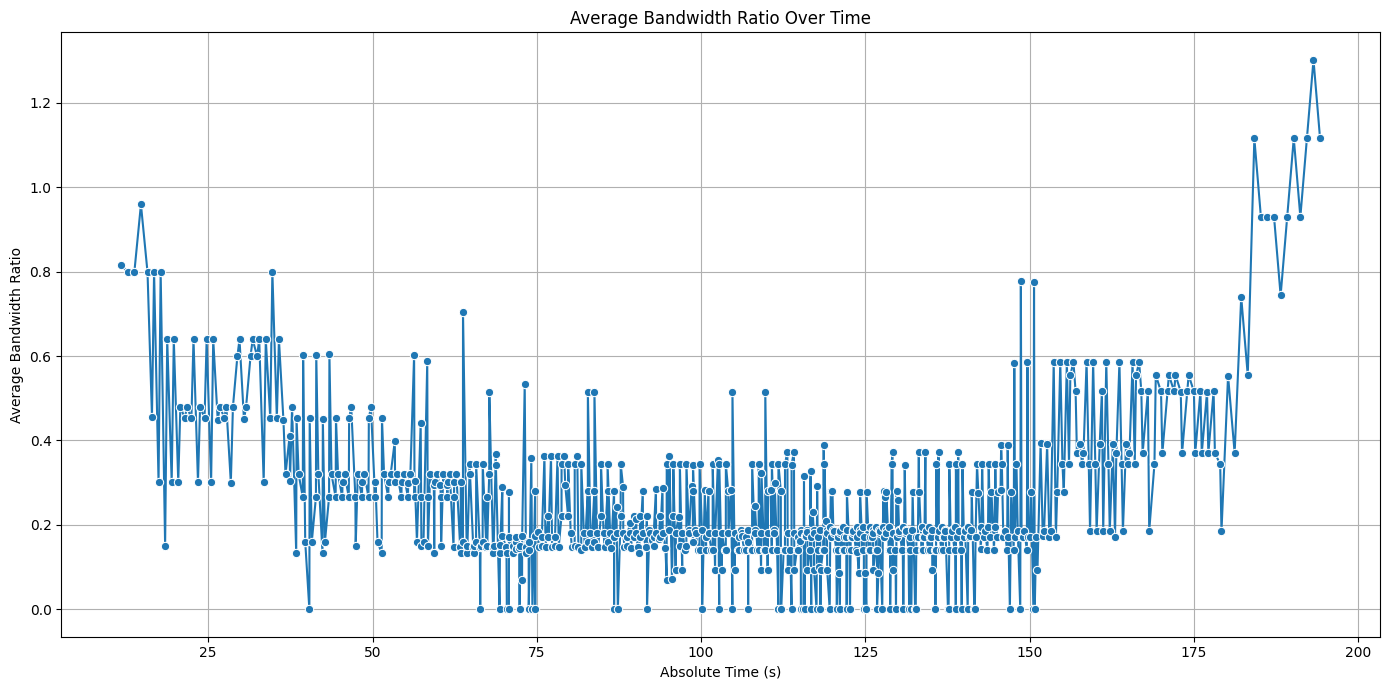

In [ ]:
df_flow_avg_ratio = df.groupby(['absolute_time_s'])['achieved_target_ratio'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_flow_avg_ratio,
    x='absolute_time_s',
    y='achieved_target_ratio',
    marker='o', # Add markers to show individual data points
    dashes=False # Ensure distinct lines if there are many flow_ids
)

plt.title('Average Bandwidth Ratio Over Time')
plt.xlabel('Absolute Time (s)')
plt.ylabel('Average Bandwidth Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

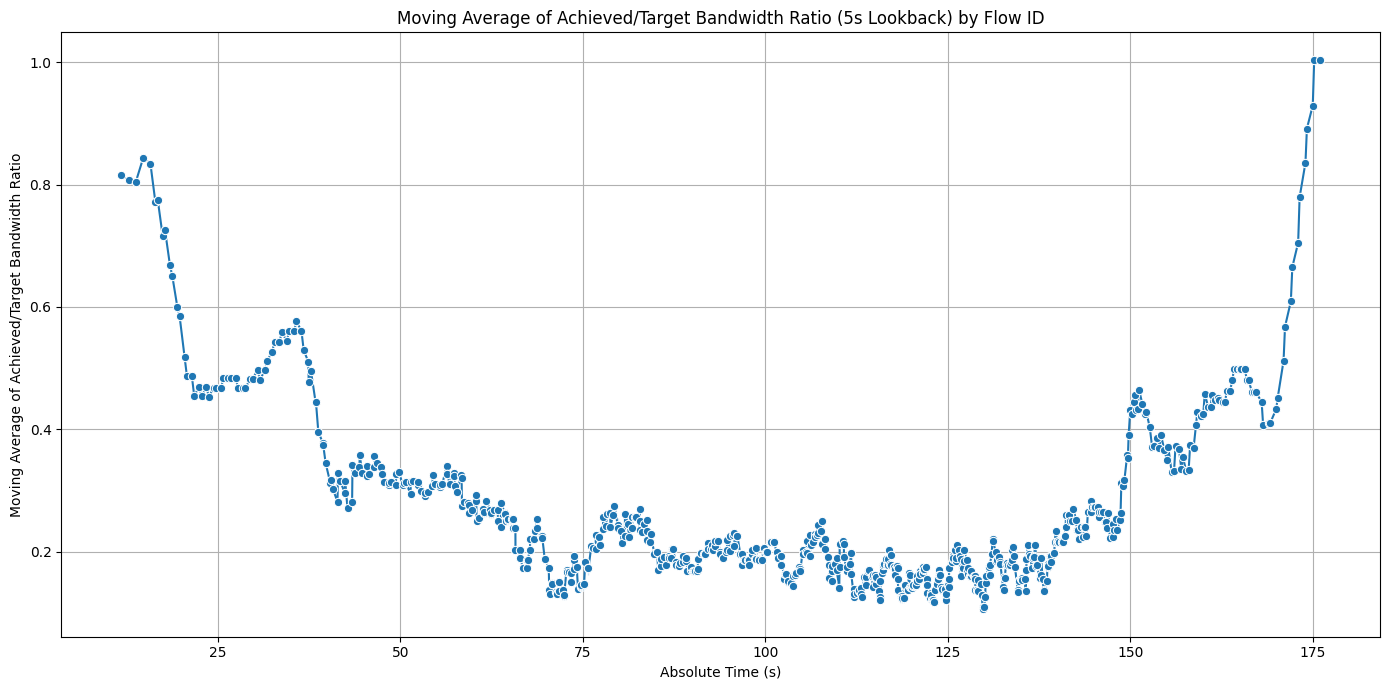

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the moving average of 'achieved_target_ratio' with a 5-second lookback
df['achieved_target_ratio_ma_5s'] = df_flow_avg_ratio['achieved_target_ratio'].rolling(window=10, min_periods=1).mean().reset_index(level=0, drop=True)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df,
    x='absolute_time_s',
    y='achieved_target_ratio_ma_5s',
    marker='o', # Add markers to show individual data points
    dashes=False # Ensure distinct lines if there are many flow_ids
)

plt.title('Moving Average of Achieved/Target Bandwidth Ratio (5s Lookback) by Flow ID')
plt.xlabel('Absolute Time (s)')
plt.ylabel('Moving Average of Achieved/Target Bandwidth Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

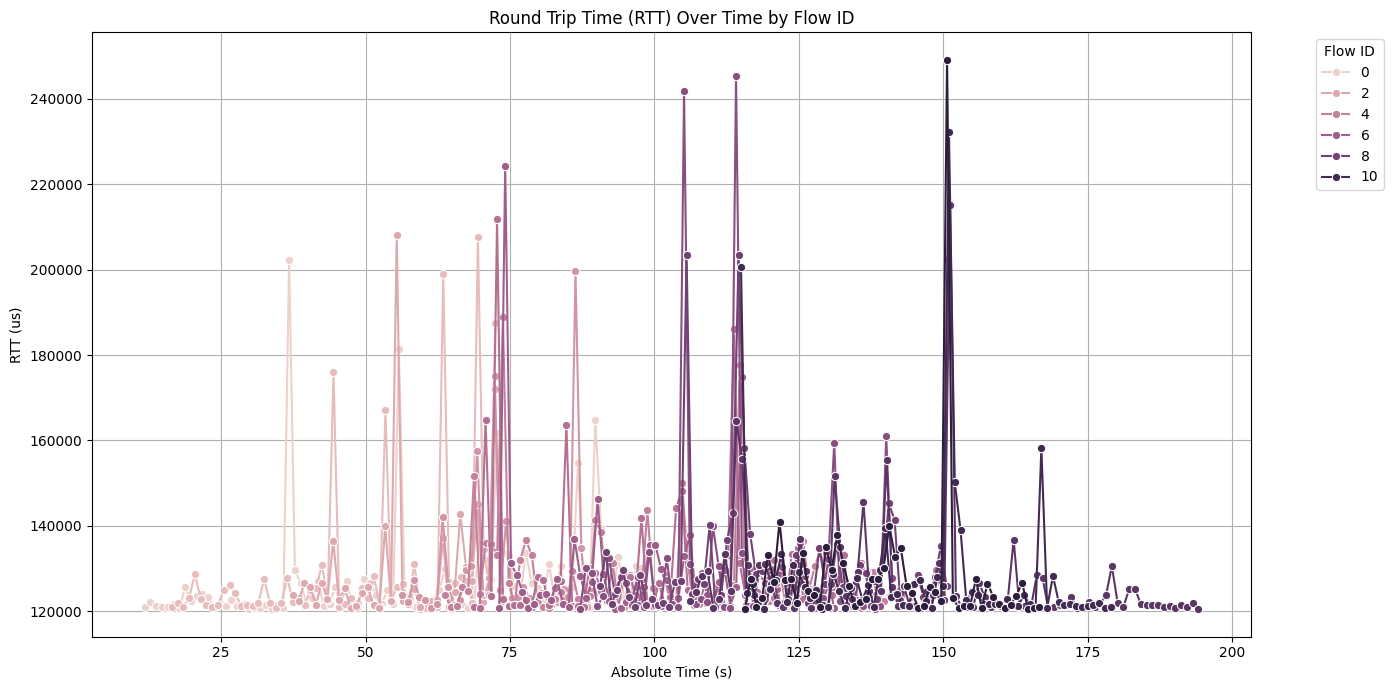

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df,
    x='absolute_time_s',
    y='rtt_us',
    hue='flow_id',
    marker='o',
    dashes=False
)

plt.title('Round Trip Time (RTT) Over Time by Flow ID')
plt.xlabel('Absolute Time (s)')
plt.ylabel('RTT (us)')
plt.grid(True)
plt.legend(title='Flow ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

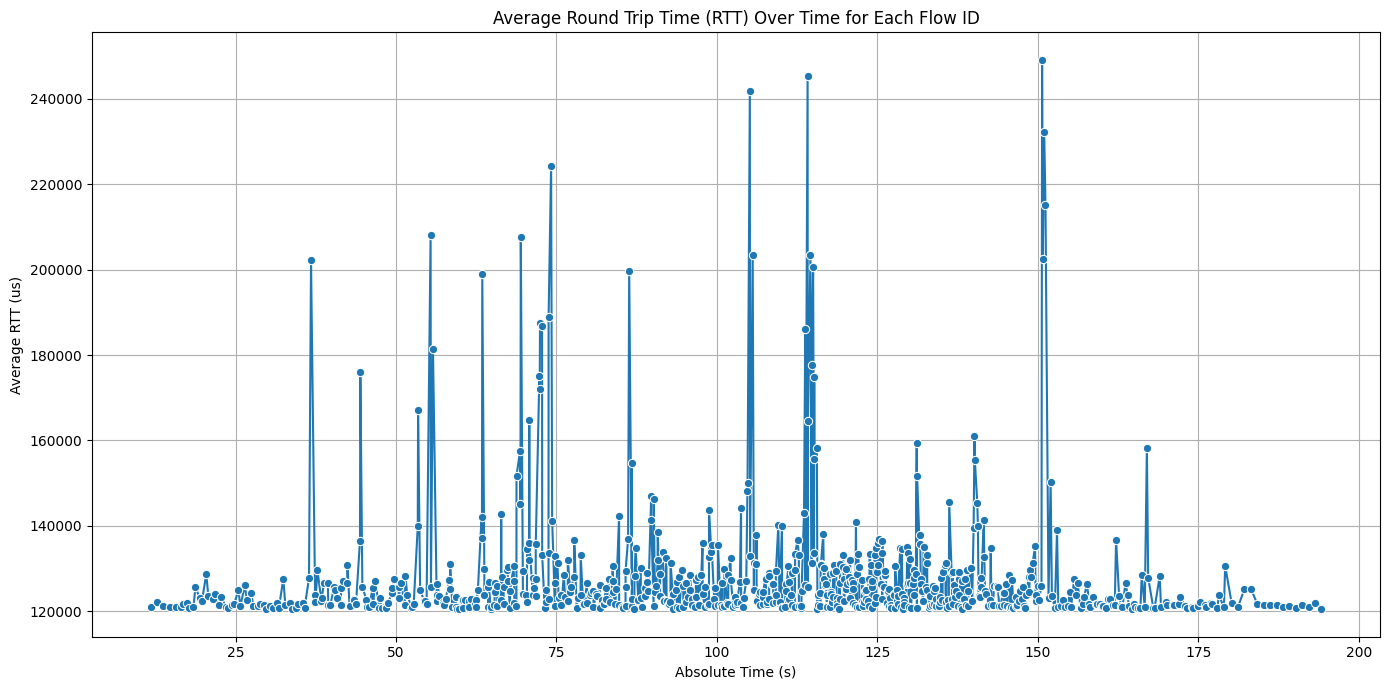

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average RTT for each flow_id at each absolute_time_s
# This makes the averaging explicit, even if (flow_id, absolute_time_s) is already unique.
df_flow_avg_rtt = df.groupby(['absolute_time_s'])['rtt_us'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_flow_avg_rtt,
    x='absolute_time_s',
    y='rtt_us',
    marker='o', # Add markers to show individual data points
    dashes=False # Ensure distinct lines if there are many flow_ids
)

plt.title('Average Round Trip Time (RTT) Over Time for Each Flow ID')
plt.xlabel('Absolute Time (s)')
plt.ylabel('Average RTT (us)')
plt.grid(True)
plt.tight_layout()
plt.show()

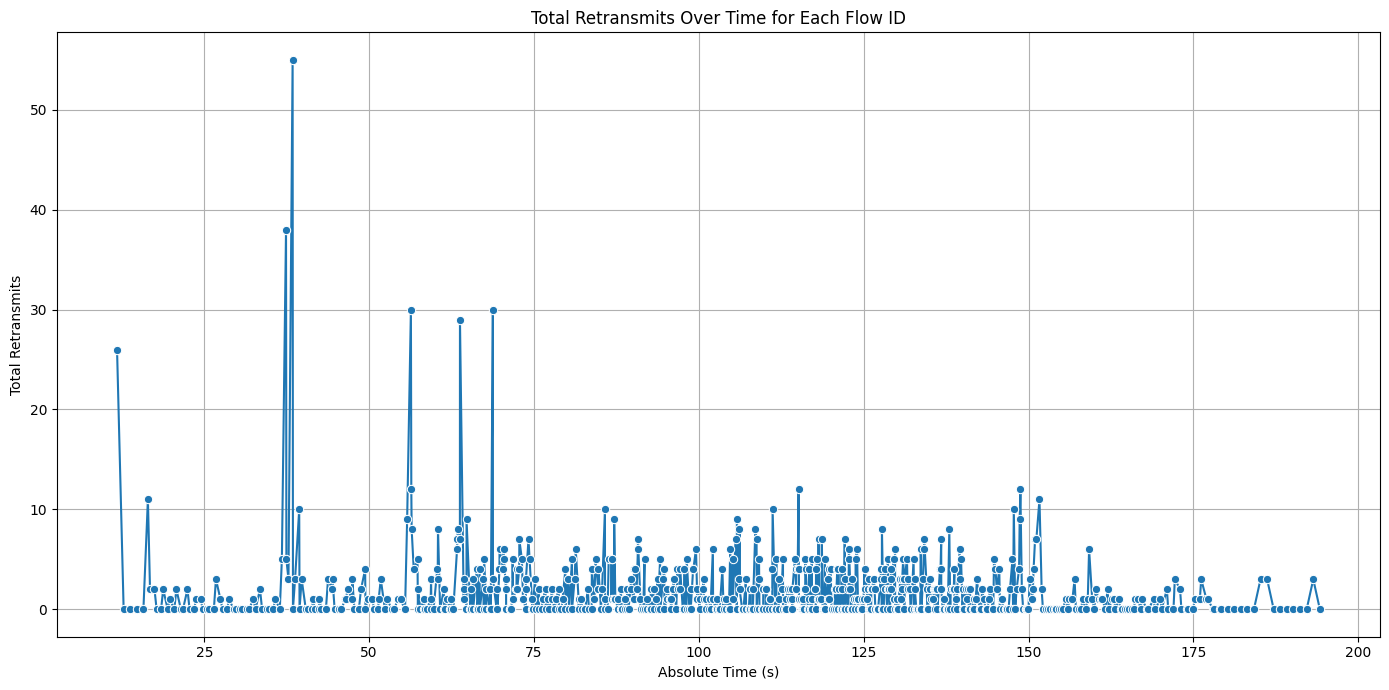

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average RTT for each flow_id at each absolute_time_s
# This makes the averaging explicit, even if (flow_id, absolute_time_s) is already unique.
df_flow_avg_retramsmits = df.groupby(['absolute_time_s'])['retransmits'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_flow_avg_retramsmits,
    x='absolute_time_s',
    y='retransmits',
    marker='o', # Add markers to show individual data points
    dashes=False # Ensure distinct lines if there are many flow_ids
)

plt.title('Total Retransmits Over Time for Each Flow ID')
plt.xlabel('Absolute Time (s)')
plt.ylabel('Total Retransmits')
plt.grid(True)
plt.tight_layout()
plt.show()